In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os, warnings
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
warnings.filterwarnings('ignore')

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

In [3]:
train_data=pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
test_data=pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
submissions=pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

In [4]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [5]:
test_data.shape

(250000, 11)

In [6]:
train_data.shape

(750000, 12)

# Exploratory Data Analysis

In [7]:
train_data.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


### Observations:
 Range of
1. Episode_Lenght_minutes is 0 to 325.24
2. Host_Popularity Percentage is 1.3 to 119.46
3. Guest_Popularity percentage is 0 to 119.91
4. Number of ads is 0 to 103.91
5. Listening_time_minutes range is 0 to 119.97

In [8]:
train_data[train_data['Number_of_Ads']==103]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
436577,436577,Sports Central,Episode 64,115.25,Sports,28.58,Saturday,Afternoon,23.65,103.0,Neutral,103.12686


In [9]:
train_data[train_data['Listening_Time_minutes']==0].value_counts().sum()

4967

This is like 0.66% of data, 2 approachs can use is either delete those rows or else create another feature,as these are outliers, will detect them and change it, as even though it is small it will affect model ## do outlier detection using IQR

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [11]:
train_data.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [12]:
test_data.isnull().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

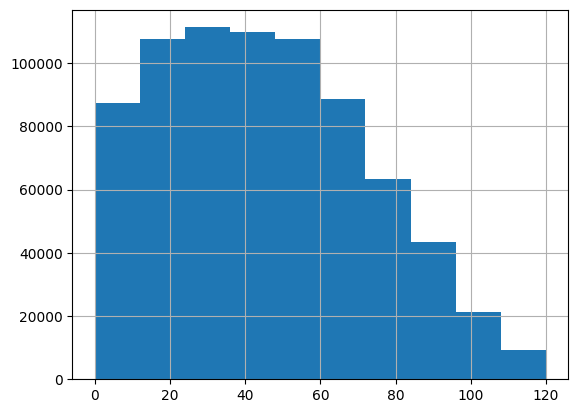

In [13]:
train_data['Listening_Time_minutes'].hist()
plt.show()

## 1. Categorical variables

In [14]:
cat_features=[feature for feature in train_data.columns if train_data[feature].dtype=='O'and feature not in ['Episode_Title']]
cat_features

['Podcast_Name',
 'Genre',
 'Publication_Day',
 'Publication_Time',
 'Episode_Sentiment']

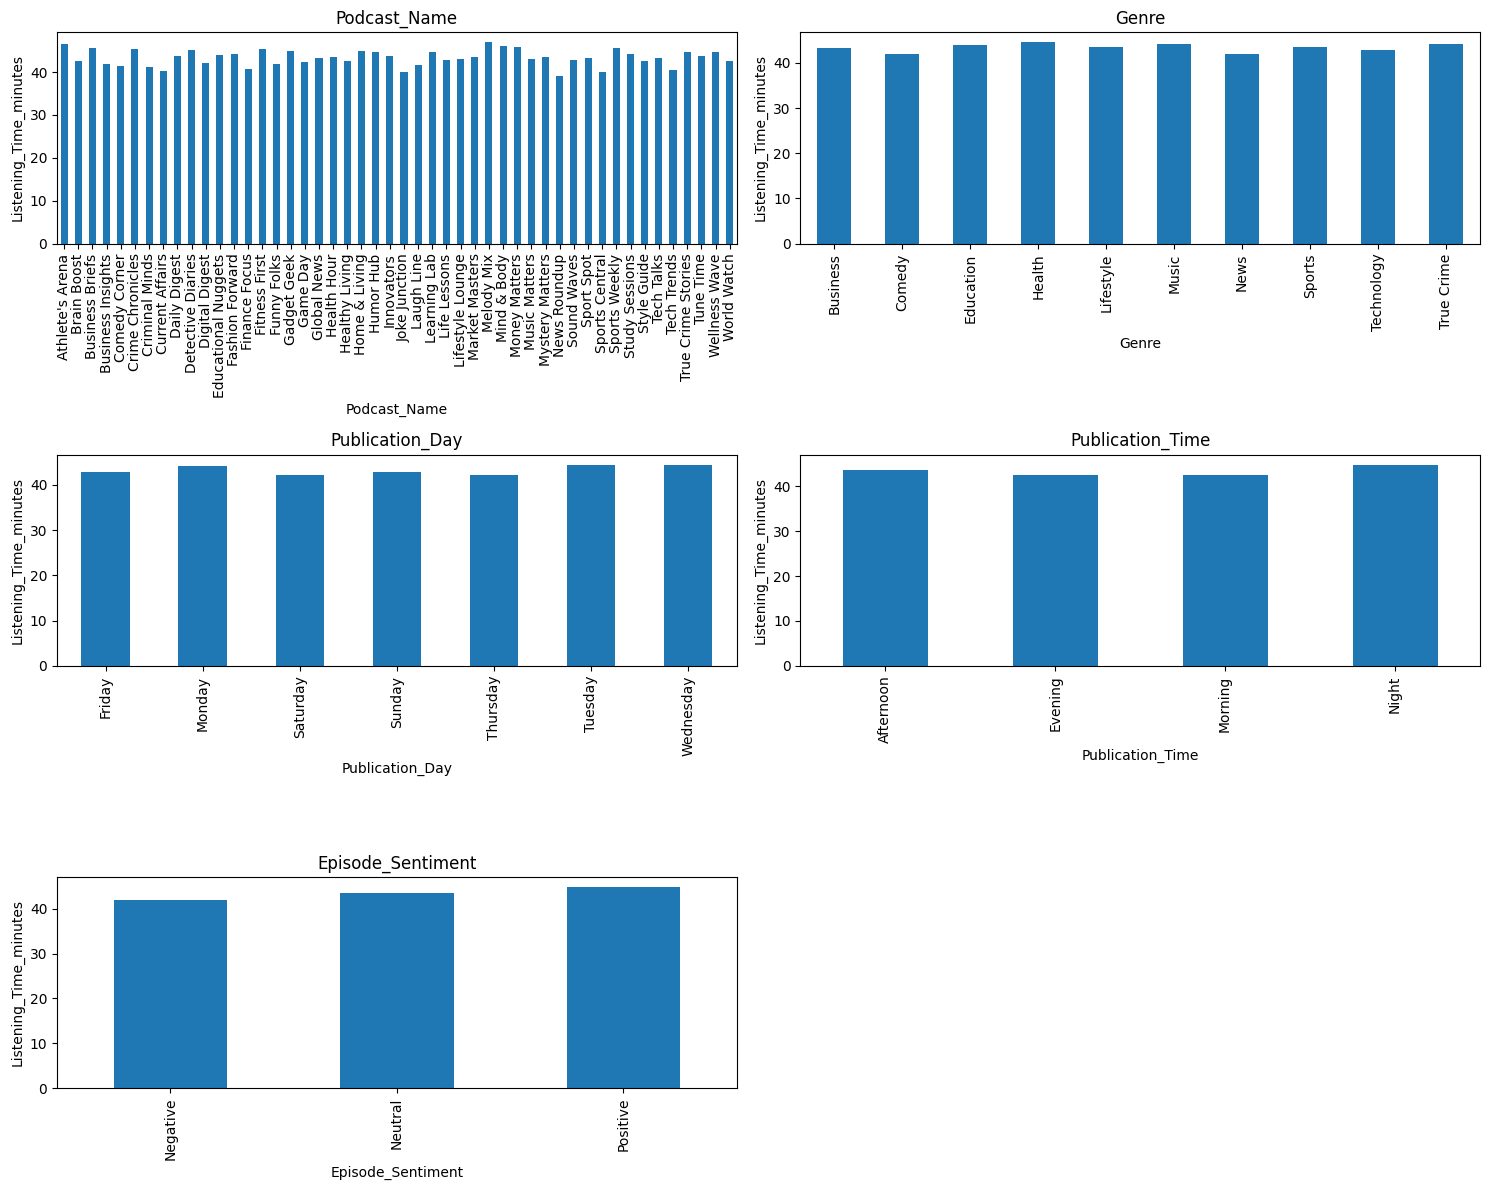

In [15]:
n_cols=2
n_rows=int(np.ceil(len(cat_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() 

for idx, feature in enumerate(cat_features):
    data=train_data.copy()
    data.groupby(feature)['Listening_Time_minutes'].median().plot.bar(ax=axes[idx])
    axes[idx].set_title(feature)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Listening_Time_minutes')


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We can see even distribution in categorical features, i.e data isn't imbalance or bias.

## 2. Numerical Features

In [16]:
num_features = [feature for feature in train_data.columns if train_data[feature].dtype != 'O' and feature not in ['id']]
num_features

['Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Guest_Popularity_percentage',
 'Number_of_Ads',
 'Listening_Time_minutes']

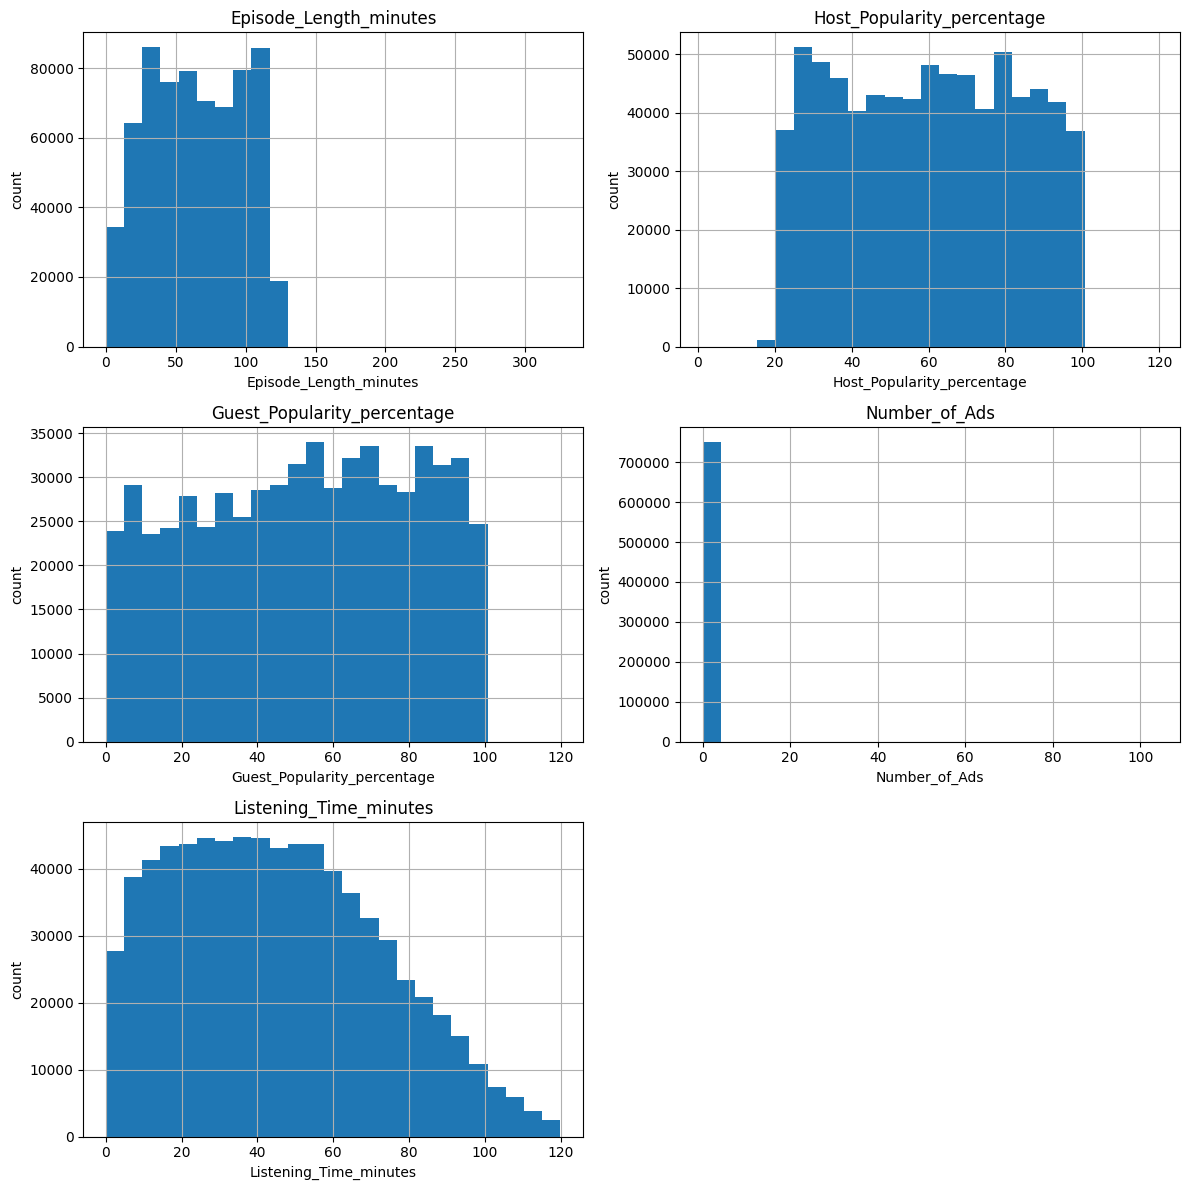

In [17]:
n_cols=2
n_rows=int(np.ceil(len(num_features)/2))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()  # Flatten in case it's a 2D array

for idx,feature in enumerate(num_features):
    train_data[feature].hist(bins=25,ax=axes[idx])
    axes[idx].set_title(feature)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('count')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

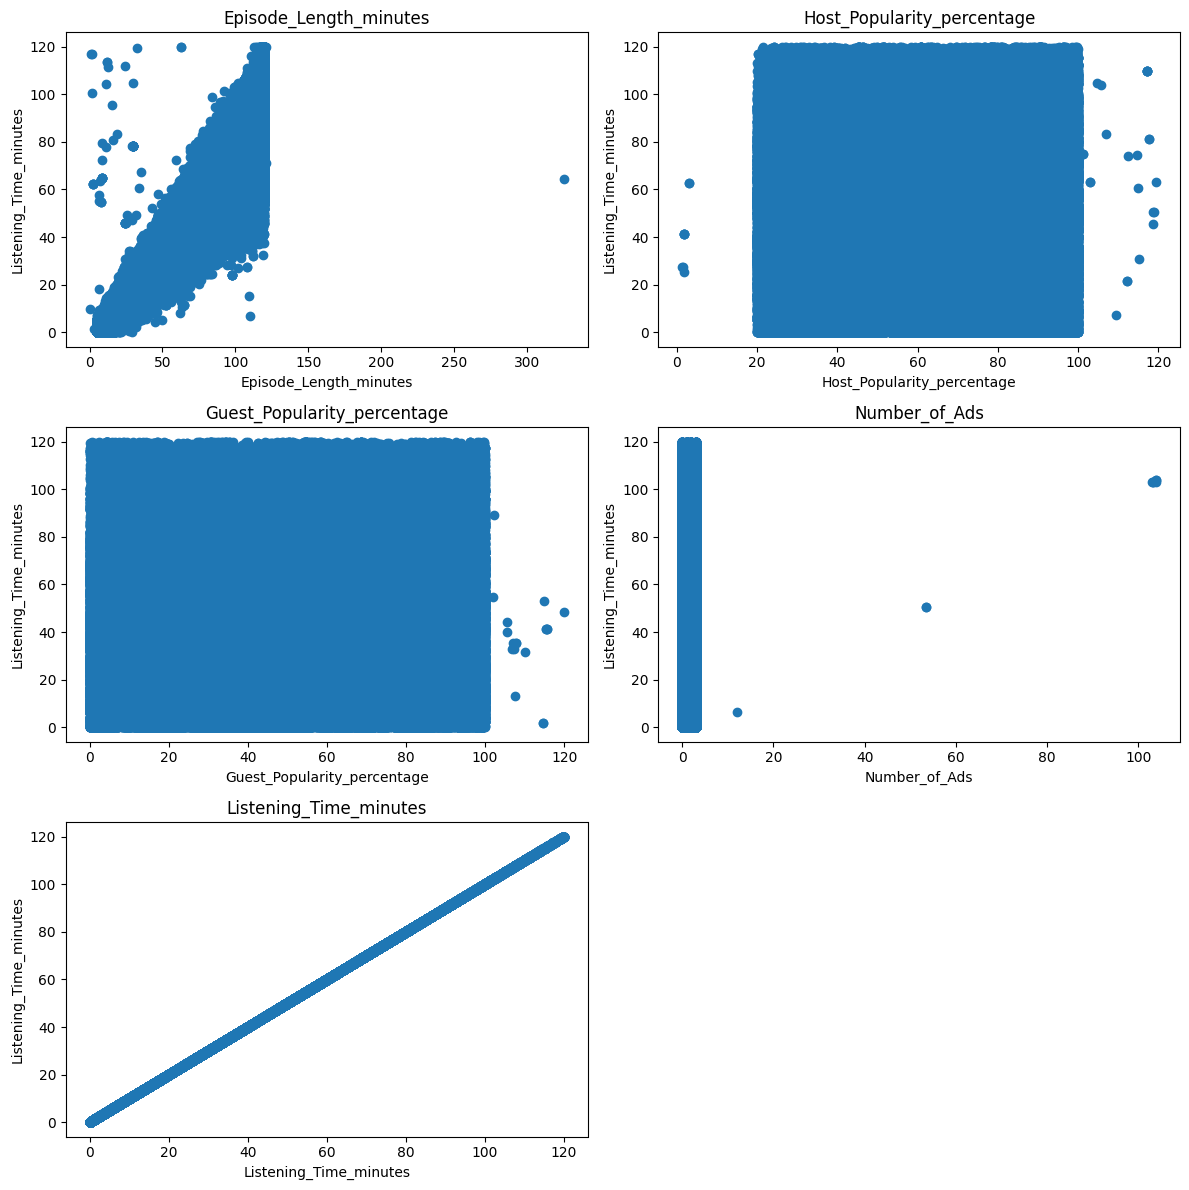

In [18]:
n_cols=2
n_rows=int(np.ceil(len(num_features)/2))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()  # Flatten in case it's a 2D array

for idx,feature in enumerate(num_features):
    axes[idx].scatter(train_data[feature],train_data['Listening_Time_minutes'])
    axes[idx].set_title(feature)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Listening_Time_minutes')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation:**
* Episode_length_minutes and listening_time_minutes(dependent variable) seems to have positive relationship i.e listening time increases with episode durarion about till 120 minutes,and then it's flat
* The scatterplot between host_popularity and guest_popularity percentage shows little to no trend among them and y. To see pattern we can make heatmap(correlation)

### Checking for outliers in numerical variable

Text(0.5, 1.0, 'BoxPlot of Episode Length Minutes')

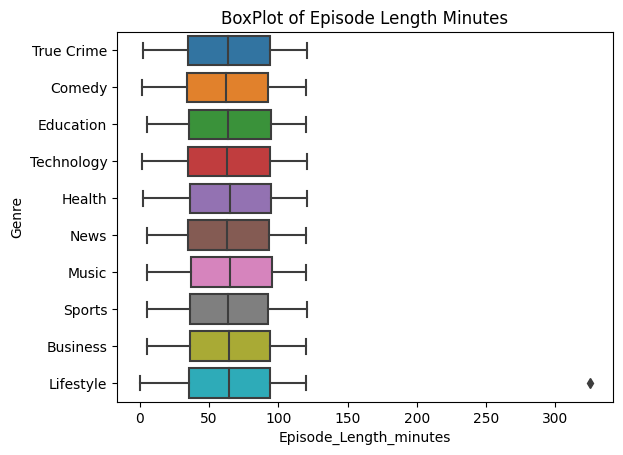

In [19]:
sns.boxplot(x='Episode_Length_minutes',y='Genre',data=train_data)
plt.title("BoxPlot of Episode Length Minutes")

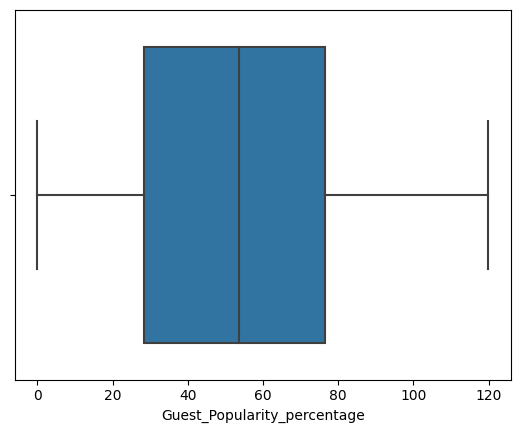

In [20]:
#train_data['Guest_Popularity_percentage'].hist()
sns.boxplot(x='Guest_Popularity_percentage', data=train_data)
plt.show()

# Feature Engineering

In [21]:
#filling missing values
#train_data['Episode_Length_minutes']=train_data['Episode_Length_minutes'].fillna(train_data['Episode_Length_minutes'].mean()) instead of mean I am using different stratergy
train_data['Episode_Length_minutes'] = train_data.groupby('Genre')['Episode_Length_minutes'].transform(
    lambda x: x.fillna(x.median()))

train_data['Guest_Popularity_percentage']=train_data['Guest_Popularity_percentage'].fillna(train_data['Guest_Popularity_percentage'].median())
train_data['Number_of_Ads']=train_data['Number_of_Ads'].fillna(0)

In [22]:
#filling missing values in test data 
test_data['Episode_Length_minutes'] = test_data.groupby('Genre')['Episode_Length_minutes'].transform(
    lambda x: x.fillna(x.median()))
test_data['Guest_Popularity_percentage']=test_data['Guest_Popularity_percentage'].fillna(test_data['Guest_Popularity_percentage'].median())

In [23]:
train_data.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64

## Outlier detection and handling

As checked in EDA there are certain outliers in data, like 103 ads for 102 mins episode and some where listening time==0

In [24]:
def cap_outliers(df, features):
    df = df.copy()
    for feature in features:
        lower = df[feature].quantile(0.01)
        upper = df[feature].quantile(0.99)
        df[feature] = df[feature].clip(lower=lower, upper=upper)
    return df

In [25]:
outlier_features=['Episode_Length_minutes','Number_of_Ads','Listening_Time_minutes']
df_capped = cap_outliers(train_data, outlier_features)
outlier_features_test=['Episode_Length_minutes','Number_of_Ads']
test_df=cap_outliers(test_data,outlier_features_test)

In [26]:
#making new features on capped and replaced data set to capture the interactions between features
def preprocess_and_engineer(df):
    df = df.copy()
    df.drop(['Episode_Title'],axis=1,inplace=True)
    # Ad rate (ads per minute)
    df['Ad_Rate'] = df['Number_of_Ads'] / (df['Episode_Length_minutes'] + 0.01)
    
    # Host - Guest popularity gap
    df['Host_Guest_Gap'] = df['Host_Popularity_percentage'] - df['Guest_Popularity_percentage']
    
    # Episode length category
    df['Is_Short_Episode'] = (df['Episode_Length_minutes'] < 10).astype(int)
    
    # Encode Sentiment
    sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    df['Episode_Sentiment_Encoded'] = df['Episode_Sentiment'].map(sentiment_map)

    # --- Interactions ---
    df['Ads_x_Sentiment'] = df['Number_of_Ads'] * df['Episode_Sentiment_Encoded']
    df['Host_x_Guest'] = df['Host_Popularity_percentage'] * df['Guest_Popularity_percentage']
    df['Length_x_Sentiment'] = df['Episode_Length_minutes'] * df['Episode_Sentiment_Encoded']
    df['Length_x_Ads'] = df['Episode_Length_minutes'] * df['Number_of_Ads']

    # --- One-hot encode small categoricals ---
    df = pd.get_dummies(df, columns=['Publication_Time','Publication_Day', 'Genre'], drop_first=True,dtype=int)
    
    return df


In [27]:
df_capped=preprocess_and_engineer(df_capped)

le=LabelEncoder()
df_capped['Podcast_Name']=le.fit_transform(df_capped['Podcast_Name'])
df_capped.drop(['Episode_Sentiment'],axis=1,inplace=True)

df_capped.head()

,id,Podcast_Name,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,Ad_Rate,Host_Guest_Gap,Is_Short_Episode,...,Publication_Day_Wednesday,Genre_Comedy,Genre_Education,Genre_Health,Genre_Lifestyle,Genre_Music,Genre_News,Genre_Sports,Genre_Technology,Genre_True Crime
0,0,34,63.80,74.81,53.58,0.0,31.41998,0.000000,21.23,0,...,0,0,0,0,0,0,0,0,0,1
1,1,24,118.89,66.95,75.95,2.0,88.01241,0.016821,-9.00,0,...,0,1,0,0,0,0,0,0,0,0
2,2,40,73.90,69.97,8.97,0.0,44.92531,0.000000,61.00,0,...,0,0,1,0,0,0,0,0,0,0
3,3,10,67.17,57.22,78.70,2.0,46.27824,0.029771,-21.48,0,...,0,0,0,0,0,0,0,0,1,0
4,4,31,110.51,80.07,58.68,3.0,75.61031,0.027144,21.39,0,...,0,0,0,1,0,0,0,0,0,0


In [28]:
test_df=preprocess_and_engineer(test_df)

test_df['Podcast_Name']=le.transform(test_df['Podcast_Name'])
test_df.drop(['Episode_Sentiment'],axis=1,inplace=True)
test_df.head()

,id,Podcast_Name,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Ad_Rate,Host_Guest_Gap,Is_Short_Episode,Episode_Sentiment_Encoded,...,Publication_Day_Wednesday,Genre_Comedy,Genre_Education,Genre_Health,Genre_Lifestyle,Genre_Music,Genre_News,Genre_Sports,Genre_Technology,Genre_True Crime
0,750000,11,78.96,38.11,53.33,1.0,0.012663,-15.22,0,1,...,0,0,1,0,0,0,0,0,0,0
1,750001,36,27.87,71.29,53.36,0.0,0.000000,17.93,0,1,...,0,0,0,0,0,1,0,0,0,0
2,750002,24,69.10,67.89,97.51,0.0,0.000000,-29.62,0,2,...,0,1,0,0,0,0,0,0,0,0
3,750003,4,115.39,23.40,51.75,2.0,0.017331,-28.35,0,2,...,0,1,0,0,0,0,0,0,0,0
4,750004,27,72.32,58.10,11.30,2.0,0.027651,46.80,0,1,...,1,0,0,0,1,0,0,0,0,0


## Categorical Encoding

Before encoding categorical variables we need to check for number of unique categories so we can select which techinique to use. Also as episode title is just Episode 98, or similar so dropping that column

In [29]:
for feature in cat_features:
    print("Number of unique {} {}".format(feature,len(train_data[feature].unique())))

Number of unique Podcast_Name 48
Number of unique Genre 10
Number of unique Publication_Day 7
Number of unique Publication_Time 4
Number of unique Episode_Sentiment 3


Based on unique categories I will use different types of encoding like label encoding, mapping and one hot encoding. One draw back of one hot encoding is it will increase number of columns in dataset.

**I am making copies of data so I can use separate for CatBoost without encoding**

In [30]:
train_data.drop(['Episode_Title'],axis=1,inplace=True)
test_data.drop(['Episode_Title'],axis=1,inplace=True)

In [31]:
train_encoded=train_data.copy()
test_encoded=test_data.copy()

# using label encoding for podcast name
le=LabelEncoder()
train_encoded['Podcast_Name']=le.fit_transform(train_encoded['Podcast_Name'])
test_encoded['Podcast_Name']=le.transform(test_encoded['Podcast_Name'])

train_encoded['Episode_Sentiment'].unique()

#Mapping sentiment
sentiment_mapping={'Negative':0,'Neutral':1,'Positive':2}
train_encoded['Episode_Sentiment']=train_encoded['Episode_Sentiment'].map(sentiment_mapping)
test_encoded['Episode_Sentiment']=test_encoded['Episode_Sentiment'].map(sentiment_mapping)

#One hot encoding on Genre, publication_day, publication_time
train_encoded = pd.get_dummies(train_encoded, columns=['Genre', 'Publication_Day', 'Publication_Time'],dtype=int, drop_first=True)
test_encoded = pd.get_dummies(test_encoded, columns=['Genre', 'Publication_Day', 'Publication_Time'],dtype=int, drop_first=True)

# Model Training 

I am using CatBoost which has inbuilt function to handle categorical features, so I have split my dataset train_encoded, test_encoded which has encoding and other without it, will compare RMSE to determine the best.

X_train, X_val,y_train,y_val=train_test_split(train_encoded.drop(['Listening_Time_minutes'],axis=1),train_encoded['Listening_Time_minutes'],test_size=0.2,random_state=42)

Using Outlier Capped Data

In [32]:
X_train,X_val,y_train,y_val=train_test_split(df_capped.drop(['Listening_Time_minutes'],axis=1),df_capped['Listening_Time_minutes'],test_size=0.2,random_state=42)

## 1.  XGBoost Model with encoded data

In [33]:
xgb_model = XGBRegressor(
    n_estimators=800, 
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,   # L2
    reg_alpha=0.5,  # L1
    random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f"XGBoost RMSE: {xgb_rmse:.4f}")

#CV scores
rmse_scorer = make_scorer(mean_squared_error, squared=False)
scores = cross_val_score(
    xgb_model,
    df_capped.drop(['Listening_Time_minutes'], axis=1),
    df_capped['Listening_Time_minutes'],
    scoring=rmse_scorer,
    cv=5
)

print(f"XGBoost CV RMSE: {np.mean(scores):.4f}")

XGBoost RMSE: 12.9282
XGBoost CV RMSE: 12.9828


Capped: 
* XGBoost RMSE: 12.9282
* XGBoost CV RMSE: 12.9828
Replaced:
* XGBoost RMSE: 13.9484
* XGBoost CV RMSE: 14.0003

## 2. CatBoost Model with encoded data

cat_model_1 =CatBoostRegressor(
    depth=6,              # shallower trees = less overfitting
    l2_leaf_reg=5,       # stronger regularization
    learning_rate=0.05,   # slower, more stable learning
    iterations=800,      # more trees to balance lower learning rate
    verbose=0,
    random_state=42
)
cat_model_1.fit(X_train,y_train)
cat_preds = cat_model_1.predict(X_val)
cat_rmse = np.sqrt(mean_squared_error(y_val, cat_preds))
print(f"CatBoost RMSE: {cat_rmse:.4f}")

rmse_scorer = make_scorer(mean_squared_error, squared=False)
scores = cross_val_score(cat_model_1,train_encoded.drop(['Listening_Time_minutes'],axis=1),train_encoded['Listening_Time_minutes'], scoring=rmse_scorer, cv=5)

print(f"Average CV RMSE: {np.mean(scores):.4f}")

## 3. CatBoost Model without encoded data

X_cat =train_data.drop(['Listening_Time_minutes'],axis=1)
y_cat = train_data['Listening_Time_minutes']
X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

train_pool = Pool(X_train_cat, y_train_cat, cat_features=cat_features)
val_pool = Pool(X_val_cat, y_val_cat, cat_features=cat_features)

cat_model = CatBoostRegressor(verbose=0, random_state=42)
cat_model.fit(train_pool)
cat_preds = cat_model.predict(val_pool)
cat_rmse = np.sqrt(mean_squared_error(y_val_cat, cat_preds))
print(f"CatBoost RMSE: {cat_rmse:.4f}")

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    reg_alpha=0.5,
    random_state=42
)


lgb_model.fit(X_train, y_train)


y_pred_lgb = lgb_model.predict(X_val)


lgb_rmse = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
print(f"LightGBM Test RMSE: {lgb_rmse:.4f}")


# Submission file

In [34]:
y_pred=xgb_model.predict(test_df)

In [35]:
submissions['Listening_Time_minutes']=y_pred

In [36]:
submissions.to_csv('submission.csv', index=False)
print("Submission file saved successfully!")

Submission file saved successfully!


-> I tried CatBoost without encoded data as it has inbuilt function to handle categorical data but it didnt perform well.

-> Initial: after comparing all 3 models one with lowest rmse on train data was CatBoost on encoded data. But when used this CatBoost on test data it failed to understand patterns and rmse was 20.25

->After CV and model tuning I figured XGBoost was performing better than CatBoost- 20.200

-> I also tried using LGBM but it gave rmse as 20.20998 so best was XGBoost.

**Next Steps**
1. Trying feature engineering again
2. Making few features which can help capture noise better